## Variational Auto  Encoders

- Reference: Adapted from the Keras example
- Auto-Encoding Variational Bayes
   https://arxiv.org/abs/1312.6114

In [1]:
import tensorflow as tf

2026-05-08 01:45:05.408431: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-08 01:45:05.500595: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 01:45:05.504229: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-08 01:45:05.504246: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not ha

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Conv2D, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import metrics
from tensorflow.keras.datasets import fashion_mnist

## Fashion MNIST

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

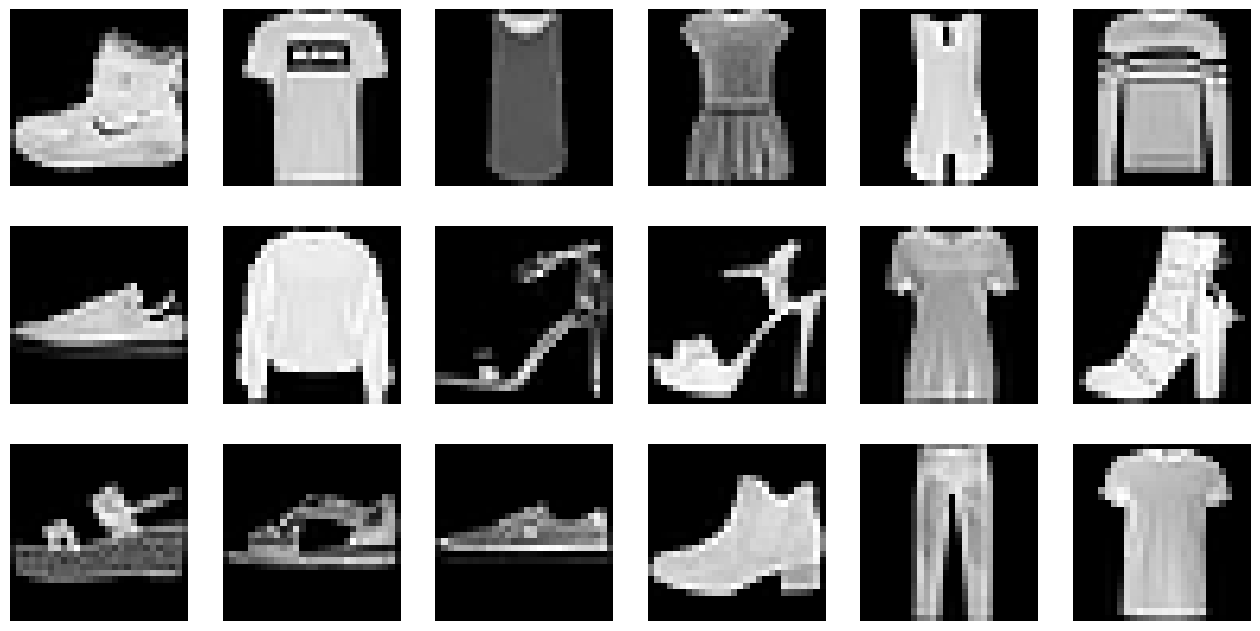

In [4]:
plt.figure(figsize=(16, 8))
for i in range(0, 18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
plt.show()

In [5]:
y_train[0:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [6]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

## Standard full-connected VAE model

Let's define a VAE model with fully connected MLPs for the encoder and decoder networks.

In [7]:
x_train_standard = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_standard = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
x_train_standard.shape, x_test_standard.shape

((60000, 784), (10000, 784))

### Encoder

In [8]:
original_dim = 784
latent_dim = 2
intermediate_dim = 256


def make_encoder(original_dim, intermediate_dim, latent_dim):
    x = Input(shape=(original_dim,))
    hidden = Dense(intermediate_dim, activation='relu')(x)
    z_mean = Dense(latent_dim)(hidden)
    z_log_var = Dense(latent_dim)(hidden)
    return Model(inputs=x, outputs=[z_mean, z_log_var],
                name="mlp_encoder")

    
encoder = make_encoder(original_dim, intermediate_dim, latent_dim)

2026-05-08 01:45:45.625903: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-08 01:45:45.628025: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-08 01:45:45.628063: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-05-08 01:45:45.628089: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-05-08 01:45:45.628112: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Co

### The VAE stochastic latent variable

<img src="./images/vae_3.svg" width="600px" />

We use the reparametrization trick to define a random variable z that is conditioned on the input image x as follows:

$$ z \sim \mathcal{N}(\mu_z(x), \sigma_z(x)) $$

The reparametrization tricks defines $z$ has follows:

$$ z = \mu_z(x) + \sigma_z(x) \cdot \epsilon$$

with:

$$ \epsilon \sim \mathcal{N}(0, 1) $$

This way the dependency to between $z$ and $x$ is deterministic and differentiable. The randomness of $z$ only stems from $\epsilon$ only for a given $x$.

Note that in practice the output of the encoder network parameterizes $log(\sigma^2_z(x)$ instead of $\sigma_z(x)$. Taking the exponential of $log(\sigma^2_z(x)$ ensures the positivity of the standard deviation from the raw output of the network:

In [9]:
def sampling_func(inputs):
    z_mean, z_log_var = inputs
    batch_size = tf.shape(z_mean)[0]
    epsilon = tf.random.normal(shape=(batch_size, latent_dim),
                              mean=0., stddev=1.)
    return z_mean + tf.exp(z_log_var / 2) * epsilon


sampling_layer = Lambda(sampling_func, output_shape=(latent_dim,),
                        name="latent_sampler")

### Decoder

In [10]:
def make_decoder(latent_dim, intermediate_dim, original_dim):
    decoder_input = Input(shape=(latent_dim,))
    x = Dense(intermediate_dim, activation='relu')(decoder_input)
    x = Dense(original_dim, activation='sigmoid')(x)
    return Model(decoder_input, x, name="mlp_decoder")


decoder = make_decoder(latent_dim, intermediate_dim, original_dim)

By default the decoder outputs has random weights and output noise:

1/1 [==============================] - 0s 15ms/step


(-0.5, 27.5, 27.5, -0.5)

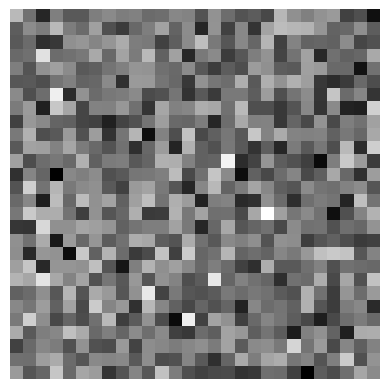

In [12]:
random_z_from_prior = np.random.normal(loc=0, scale=1, size=(1, latent_dim))
generated = decoder.predict(random_z_from_prior)
plt.imshow(generated.reshape(28, 28), cmap=plt.cm.gray)
plt.axis('off')

The generated image is completely univariate noise: there is no apparent spatial depenedencies between the pixel values. This reflects the lack of prior structure in the randomly initialized fully-connected decoder network. 


Let's now the plug the encoder and decoder via the stochastic latent variable $z$ to get the full VAE architecture. The loss function is the negative ELBO of the variational inference problem:

In [14]:
def make_vae(input_shape, encoder, decoder, sampling_layer):
    # Build de model architecture by assembling the encoder,
    # stochastic latent variable and decoder:
    x = Input(shape=input_shape, name="input")
    z_mean, z_log_var = encoder(x)
    z = sampling_layer([z_mean, z_log_var])
    x_decoded_mean = decoder(z)
    vae = Model(x, x_decoded_mean)

    # Define the VAE loss
    xent_loss = original_dim * metrics.binary_crossentropy(
        Flatten()(x), Flatten()(x_decoded_mean))
    kl_loss = - 0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
    vae_loss = tf.reduce_mean(xent_loss + kl_loss)

    vae.add_loss(vae_loss)
    vae.compile(optimizer='adam')
    return vae

vae = make_vae((original_dim,), encoder, decoder,
               sampling_layer=sampling_layer)
vae.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 784)]        0           []                               
                                                                                                  
 mlp_encoder (Functional)       [(None, 2),          201988      ['input[0][0]']                  
                                 (None, 2)]                                                       
                                                                                                  
 latent_sampler (Lambda)        (None, 2)            0           ['mlp_encoder[0][0]',            
                                                                  'mlp_encoder[0][1]']            
                                                                                              

In [15]:
vae.fit(x_train_standard, epochs=50, batch_size=100,
        validation_data=(x_test_standard, None))

Epoch 1/50
600/600 [==============================] - 6s 9ms/step - loss: 305.0829 - val_loss: 282.2659
Epoch 2/50
600/600 [==============================] - 5s 9ms/step - loss: 278.3280 - val_loss: 276.6835
Epoch 3/50
600/600 [==============================] - 6s 9ms/step - loss: 273.8539 - val_loss: 273.4550
Epoch 4/50
600/600 [==============================] - 6s 9ms/step - loss: 271.5148 - val_loss: 271.5981
Epoch 5/50
600/600 [==============================] - 5s 9ms/step - loss: 269.9770 - val_loss: 270.3695
Epoch 6/50
600/600 [==============================] - 5s 9ms/step - loss: 268.7600 - val_loss: 269.4951
Epoch 7/50
600/600 [==============================] - 5s 8ms/step - loss: 267.8743 - val_loss: 268.4338
Epoch 8/50
600/600 [==============================] - 5s 8ms/step - loss: 267.0131 - val_loss: 268.4232
Epoch 9/50
600/600 [==============================] - 5s 8ms/step - loss: 266.3595 - val_loss: 267.3418
Epoch 10/50
600/600 [==============================] - 5s 8ms/st

In [ ]:
# vae.save_weights("standard_weights.h5")

In [16]:
vae.load_weights("standard_weights.h5")

Note that the model has not yet converged even after 50 epochs. Furthermore it's is not overfitting significantly either. We chose a very low value for the latent dimension. It is likely that using the higher dimensional space could lead to a model either to optimize that would better fit the training set.

By sampling a random latent vector from the prior distribution and feeding it to the decoder we can effectively sample from the image model trained by the VAE:

(-0.5, 27.5, 27.5, -0.5)

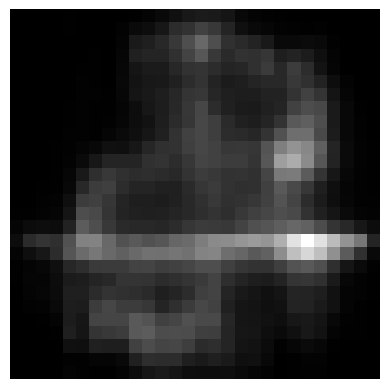

In [17]:
random_z_from_prior = np.random.normal(size=(1, latent_dim)).astype("float32")
generated = decoder(random_z_from_prior).numpy()
plt.imshow(generated.reshape(28, 28), cmap=plt.cm.gray)
plt.axis('off')

Use `Ctrl-Enter` several times to sample from various random locations in the 2D latent space.

The generated pictures are blurry but capture of the global organization of pixels required to represent samples from the 10 fashion item categories. The spatial structure has been learned and is only present in the decoder weights.

### 2D plot of the image classes in the latent space

We can also use the encoder to set the visualize the distribution of the test set in the 2D latent space of the VAE model. In the following the colors show the true class labels from the test samples.

Note that the VAE is an unsupervised model: it did not use any label information during training. However we can observe that the 2D latent space is largely structured around the categories of images used in the training set.

In [18]:
id_to_labels = {0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat", 
                5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"}

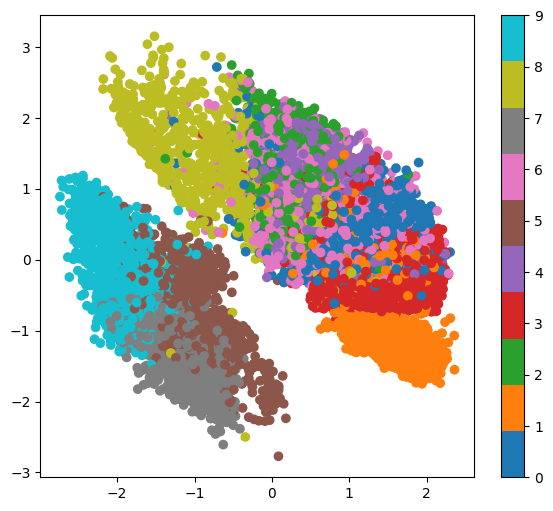

In [19]:
x_test_encoded, x_test_encoded_log_var = encoder(x_test_standard)
plt.figure(figsize=(7, 6))
plt.scatter(x_test_encoded[:, 0], x_test_encoded[:, 1], c=y_test,
            cmap=plt.cm.tab10)
cb = plt.colorbar()
cb.set_ticks(list(id_to_labels.keys()))
cb.set_ticklabels(list(id_to_labels.values()))
cb.update_ticks()
plt.show()

**Exercises**

- One can see that the class labels 5, 7 and 9 are grouped in a cluster of the latent space. Use matplotlib to display some samples from each of those 3 classes and discover why they have been grouped together by the VAE model.

- Similarly: can you qualitatively explain with matplotlib why class 0, 4 and 6 seem to be hard to disentangle in this 2D latent space discovered by the VAE model?

- One can observe that the global 2D shape of the encoded dataset is approximately spherical with values with a maximum radius of size 3. Where can you explain where the shape of this marginal latent distribution come from?

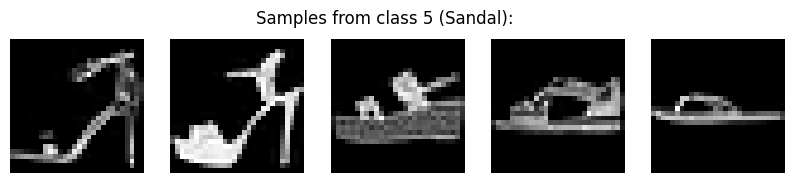

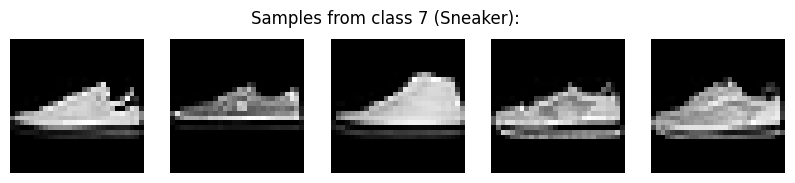

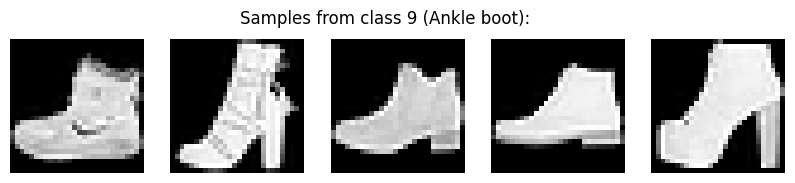

In [21]:
# %load solutions/class_5_7_9.py
for i in [5, 7, 9]:
    plt.figure(figsize=(10, 2))
    for j in range(5):
        plt.subplot(1, 5, j + 1)
        plt.imshow(x_train[y_train == i][j], cmap="gray")
        plt.axis("off")
    plt.suptitle("Samples from class %d (%s):"
                 % (i, id_to_labels[i]))
    plt.show()

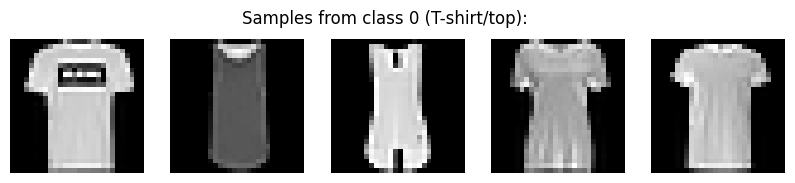

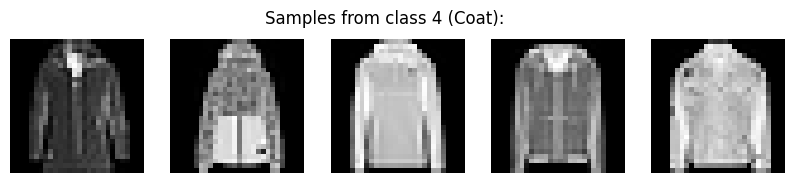

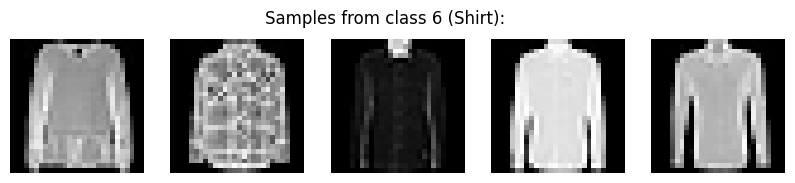

In [23]:
# %load solutions/class_0_4_6.py
for i in [0, 4, 6]:
    plt.figure(figsize=(10, 2))
    for j in range(5):
        plt.subplot(1, 5, j + 1)
        plt.imshow(x_train[y_train == i][j], cmap="gray")
        plt.axis("off")
    plt.suptitle("Samples from class %d (%s):"
                 % (i, id_to_labels[i]))
    plt.show()

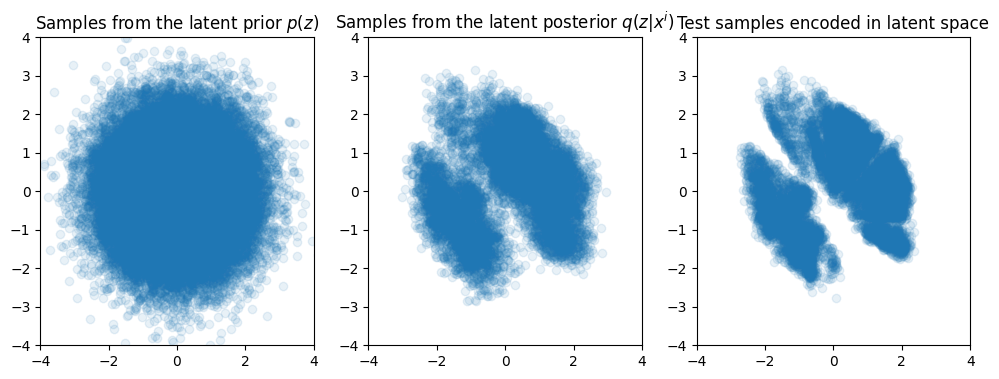

In [25]:
# %load solutions/shape_marginal_latent_distribution.py
fig, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(12, 4))

# Sample from the latent variable prior
normal_data = np.random.normal(size=(x_train.shape[0], 2))
ax0.scatter(normal_data[:, 0], normal_data[:, 1], alpha=0.1)
ax0.set_title("Samples from the latent prior $p(z)$")
ax0.set_xlim(-4, 4)
ax0.set_ylim(-4, 4)

# Sample a z_i from the conditional posterior for each x_i in the test set:
z = np.vstack([
    np.random.multivariate_normal(
        x_test_encoded[i], np.diag(np.exp(x_test_encoded_log_var[i] / 2)))
    for i in range(x_test_encoded.shape[0])])
ax1.scatter(z[:, 0], z[:, 1], alpha=0.1)
ax1.set_title("Samples from the latent posterior $q(z|x^i)$")
ax1.set_xlim(-4, 4)
ax1.set_ylim(-4, 4)

# Posterior mean value for each sample x_i from the test set:
ax2.scatter(x_test_encoded[:, 0], x_test_encoded[:, 1], alpha=0.1)
ax2.set_title("Test samples encoded in latent space")
ax2.set_xlim(-4, 4)
ax2.set_ylim(-4, 4);

# Analysis:
#
# The VAE KL divergence term of the likelihood lower bound objective function
# is trying to force the encoder to match the posterior distribution with the
# prior of the latent variable. In our case we used:
#               Normal(mean=[0, 0], std=diag([1, 1])
# as the prior distribution which means that 99.7% of the points are expected
# to lie within a radius of 3 around the origin of the 2D latent plan.
#
# Selecting different location and scale parameters for the prior (or even
# a different distribution such as the uniform distribution) would impact the
# shape of the encoded data.

### 2D panel view of samples from the VAE manifold

The following linearly spaced coordinates on the unit square were transformed through the inverse CDF (ppf) of the Gaussian to produce values of the latent variables z. This makes it possible to use a square arangement of panels that spans the gaussian prior of the latent space.

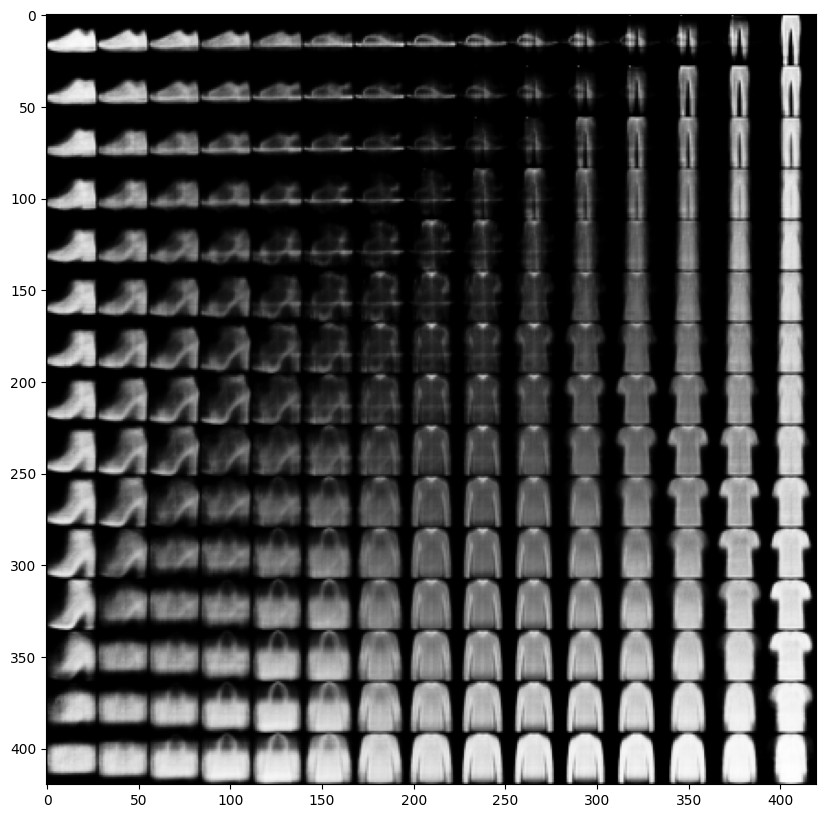

In [26]:
n = 15  # figure with 15x15 panels
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))
grid_x = norm.ppf(np.linspace(0.05, 0.95, n)).astype(np.float32)
grid_y = norm.ppf(np.linspace(0.05, 0.95, n)).astype(np.float32)

for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder(z_sample).numpy()
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='Greys_r')
plt.show()

## Anomaly detection

Let's rebuild a new VAE which encodes 9 of the 10 classes, and see if we can build a measure that shows wether the data is an anomaly
We'll call standard classes the first 9 classes, and anomalies the last class (class n°9, which is "ankle boots")

In [27]:
valid_indexes_train = y_train != 9
valid_indexes_test = y_test != 9
x_train_9 = x_train[valid_indexes_train]
x_test_9 = x_test[valid_indexes_test]
x_train_standard_9 = x_train_9.reshape((len(x_train_9), np.prod(x_train_9.shape[1:])))
x_test_standard_9 = x_test_9.reshape((len(x_test_9), np.prod(x_test_9.shape[1:])))
print(x_train_standard_9.shape, x_test_standard_9.shape)
anomalies_indexes = y_test == 9
anomalies = x_test_standard[anomalies_indexes]

(54000, 784) (9000, 784)


In [28]:
# rebuild a new encoder, decoder, and train them on the limited dataset
encoder = make_encoder(original_dim, intermediate_dim, latent_dim)
decoder = make_decoder(latent_dim, intermediate_dim, original_dim)

vae_9 = make_vae((original_dim,), encoder, decoder,
               sampling_layer=sampling_layer)
vae_9.fit(x_train_standard_9, epochs=50, batch_size=100,
        validation_data=(x_test_standard_9, None))

Epoch 1/50
540/540 [==============================] - 4s 7ms/step - loss: 305.0818 - val_loss: 281.0806
Epoch 2/50
540/540 [==============================] - 5s 9ms/step - loss: 276.0794 - val_loss: 275.2300
Epoch 3/50
540/540 [==============================] - 5s 9ms/step - loss: 272.2973 - val_loss: 272.5192
Epoch 4/50
540/540 [==============================] - 4s 8ms/step - loss: 270.3046 - val_loss: 271.5650
Epoch 5/50
540/540 [==============================] - 4s 8ms/step - loss: 268.9057 - val_loss: 269.7958
Epoch 6/50
540/540 [==============================] - 5s 9ms/step - loss: 267.8494 - val_loss: 269.2631
Epoch 7/50
540/540 [==============================] - 5s 9ms/step - loss: 267.1601 - val_loss: 268.1851
Epoch 8/50
540/540 [==============================] - 5s 9ms/step - loss: 266.5009 - val_loss: 267.7738
Epoch 9/50
540/540 [==============================] - 4s 8ms/step - loss: 266.0475 - val_loss: 267.3823
Epoch 10/50
540/540 [==============================] - 5s 9ms/st

In [ ]:
# vae_9.save_weights("standard_weights_9.h5")

In [29]:
vae_9.load_weights("standard_weights_9.h5")

In [30]:
# For simplicity, we will do our sampling with numpy not with Keras or tensorflow
def sampling_func_numpy(inputs):
    z_mean, z_log_var = inputs
    batch_size = np.shape(z_mean)[0]
    epsilon = np.random.normal(size=(batch_size, latent_dim),
                              loc=0., scale=1.).astype("float32")
    return z_mean + np.exp(z_log_var / 2) * epsilon

# Compute the reconstruction error: encode, sample, then decode. 
# To ensure we get a stable result, we'll run the sampling nb_sampling times
def compute_reconstruction_error(img, nb_sampling=10):
    if len(img.shape) == 1:
        img = np.expand_dims(img, 0)
    batch_size = np.shape(img)[0]
    img_encoded_mean_and_var = encoder(img)
    img_encoded_samples = [sampling_func_numpy(img_encoded_mean_and_var)
                           for x in range(nb_sampling)]
    # stack all samples
    img_encoded_samples = np.vstack(img_encoded_samples)
    reconstructed_samples = decoder(img_encoded_samples).numpy()
    # unstack all samples
    split_samples = reconstructed_samples.reshape(nb_sampling, batch_size, img.shape[-1])
    errors = np.linalg.norm(split_samples - img, axis=-1)
    return np.mean(errors, axis=0)

In [31]:
errors_test = compute_reconstruction_error(x_test_standard_9)

In [32]:
errors_anomalies = compute_reconstruction_error(anomalies)

In [33]:
noise = np.random.uniform(size=(1000, 784), low=0.0, high=1.0)
errors_random = compute_reconstruction_error(noise.astype(np.float32))

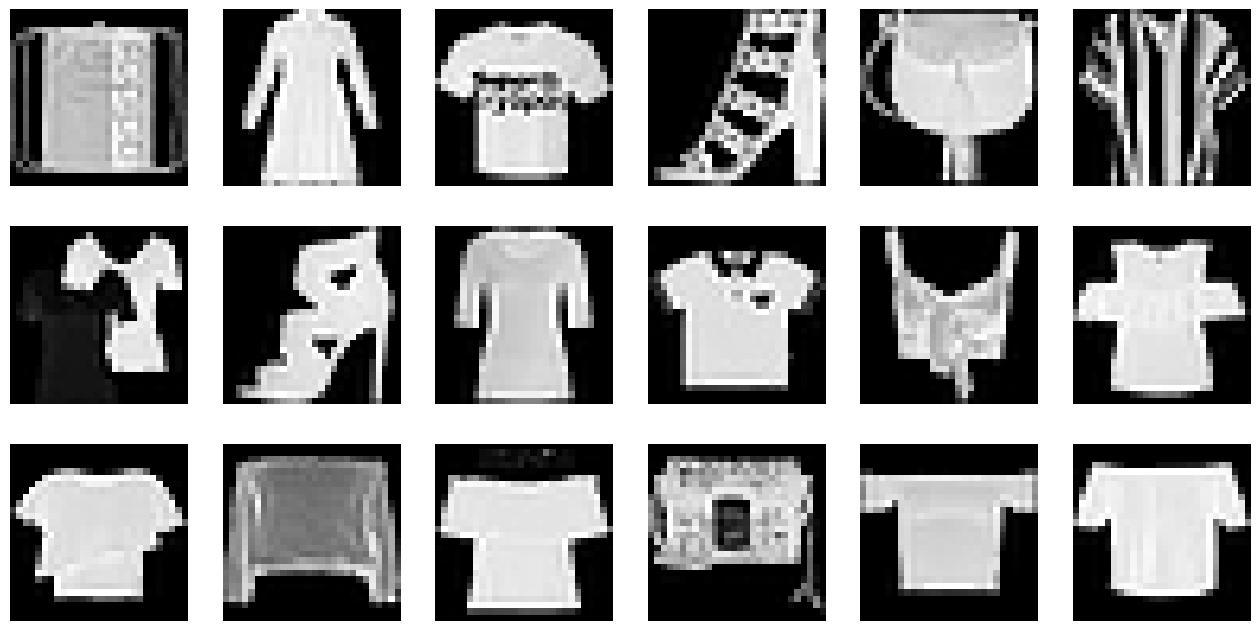

In [34]:
# most anomalous in test set
indexes = np.argsort(errors_test)[-18:]

plt.figure(figsize=(16, 8))
for i in range(0, 18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(x_test_9[indexes][i], cmap="gray")
    plt.axis("off")
plt.show()

# It shows weird shaped tops, or very complex shoes which are difficult to reconstruct

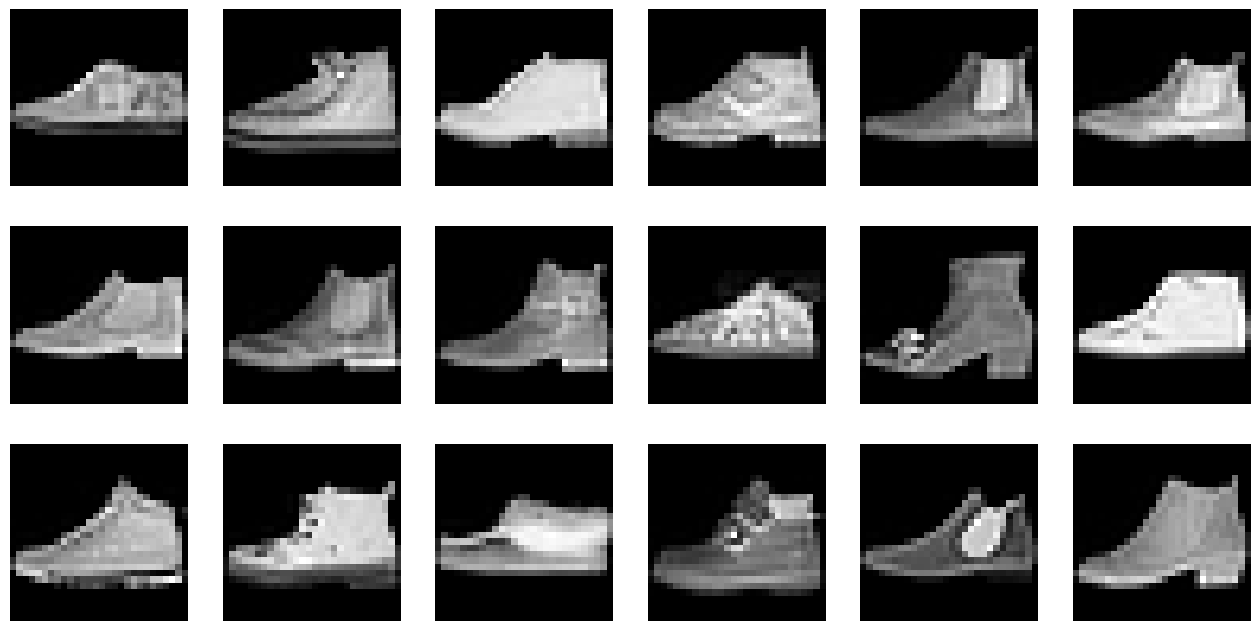

In [35]:
# most normal in anomalies test set 
indexes = np.argsort(errors_anomalies)[0:18]

plt.figure(figsize=(16, 8))
for i in range(0, 18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(x_test[anomalies_indexes][indexes][i], cmap="gray")
    plt.axis("off")
plt.show()

# Indeed most of them do not look like ankle boot (they could belong to other shoes categories)!

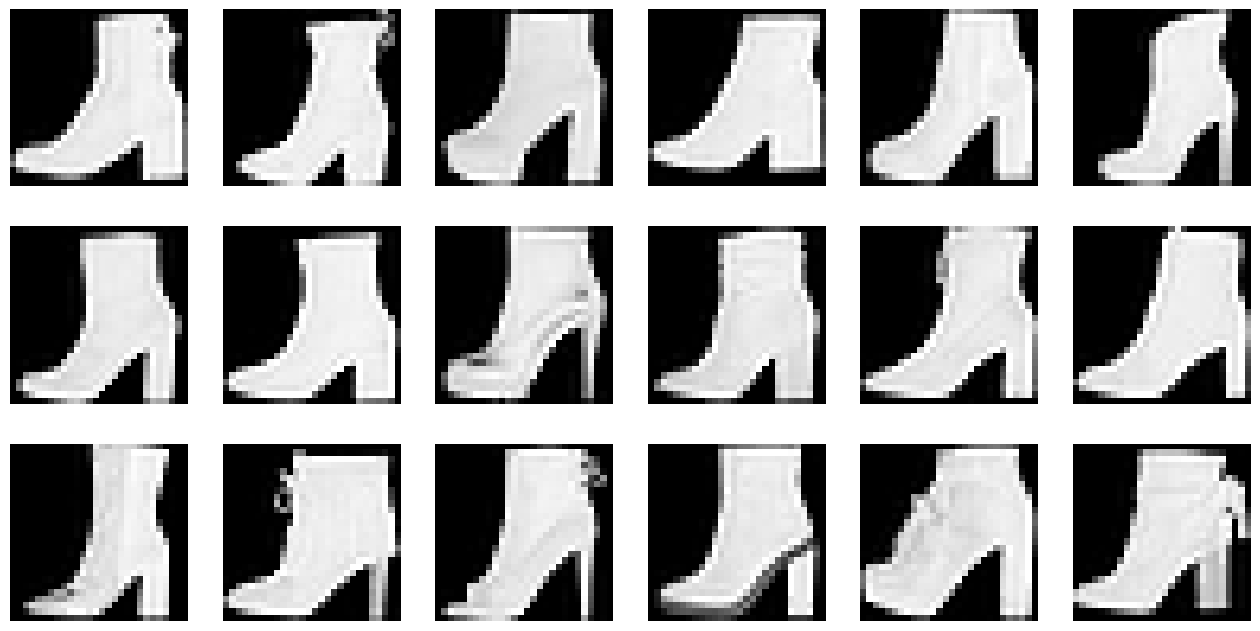

In [36]:
# most anomalous in anomalies test set 
indexes = np.argsort(errors_anomalies)[-18:]

plt.figure(figsize=(16, 8))
for i in range(0, 18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(x_test[anomalies_indexes][indexes][i], cmap="gray")
    plt.axis("off")
plt.show()

### Is this method a good anomaly detection method?

Let's compare the distribution of reconstruction errors from 
- standard test set images
- class 9 images
- random noise

What can you interpret from this graph?

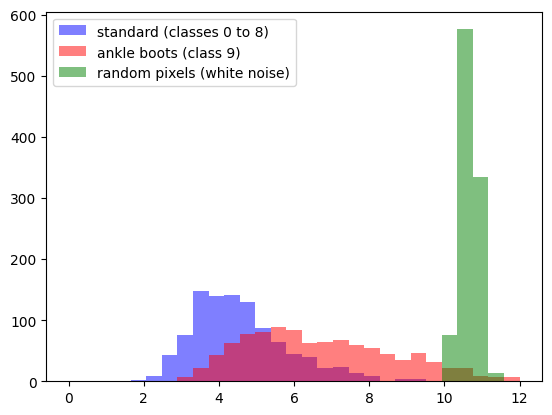

In [37]:
fig = plt.figure()
ax = fig.add_subplot(111)
bins = np.linspace(0, 12, 30)
a1 = ax.hist(np.random.choice(errors_test, 1000, replace=False), bins=bins, color="blue", alpha=0.5,)
a2 = ax.hist(errors_anomalies, bins=bins, color="red", alpha=0.5)
a3 = ax.hist(errors_random, bins=bins, color="green", alpha=0.5)
plt.legend(('standard (classes 0 to 8)', 'ankle boots (class 9)', 'random pixels (white noise)'))
plt.show()

## Convolutional Variational Auto Encoder

In [38]:
x_train_conv = np.expand_dims(x_train, -1)
x_test_conv = np.expand_dims(x_test, -1)
x_train_conv.shape, x_test_conv.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

**Exercise**: write an encoder that uses a series of convolutional layers, with maxpooling or strided convolutions and Batch norm to encode the 2D, gray-level images into 2D latent vectors:

In [ ]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Flatten,
    Dense,
    BatchNormalization,
    LeakyReLU)

from tensorflow.keras.models import Model


def make_conv_encoder(img_rows, img_cols, img_chns, latent_dim, intermediate_dim):

    inp = x = Input(shape=(img_rows, img_cols, img_chns))
    x = Conv2D(32, kernel_size=3, strides=2, padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = Conv2D(64,kernel_size=3,strides=2,padding='same')(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    x = Flatten()(x)
    x = Dense(intermediate_dim, activation='relu')(x)
    z_mean = Dense(latent_dim, name='z_mean')(x)
    z_log_var = Dense(latent_dim, name='z_log_var')(x)
    
    return Model(
        inputs=inp,
        outputs=[z_mean, z_log_var],
        name='convolutional_encoder'
    )


conv_encoder = make_conv_encoder(img_rows,img_cols,img_chns,latent_dim,intermediate_dim)
print(conv_encoder.summary())
conv_encoder.predict(x_train_conv[:1])

NameError: name 'z_mean' is not defined

In [ ]:
# %load solutions/conv_encoder.py

The stochastic latent variable is the same as for the fully-connected model.

In [ ]:
sampling_layer = Lambda(sampling_func, output_shape=(latent_dim,),
                        name="latent_sampler")

## Decoder

The decoder is also convolutional but instead of downsampling the spatial dimensions from (28, 28) to 2 latent dimensions, it starts from the latent space to upsample a (28, 28) dimensions using strided `Conv2DTranspose` layers.

Here again BatchNormalization layers are inserted after the convolution to make optimization converge faster.

In [ ]:
def make_conv_decoder(latent_dim, intermediate_dim, original_dim,
                      spatial_size=7, filters=16):
    decoder_input = Input(shape=(latent_dim,))
    x = Dense(intermediate_dim, activation='relu')(decoder_input)
    x = Dense(filters * spatial_size * spatial_size, activation='relu')(x)
    x = Reshape((spatial_size, spatial_size, filters))(x)
    # First up-sampling:
    x = Conv2DTranspose(filters,
                        kernel_size=3,
                        padding='same',
                        strides=(2, 2),
                        activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2DTranspose(filters,
                        kernel_size=3,
                        padding='same',
                        strides=1,
                        activation='relu')(x)
    x = BatchNormalization()(x)
    
    # Second up-sampling:
    x = Conv2DTranspose(filters,
                        kernel_size=3,
                        strides=(2, 2),
                        padding='valid',
                        activation='relu')(x)
    x = BatchNormalization()(x)
    # Ouput 1 channel of gray pixels values between 0 and 1:
    x = Conv2D(1, kernel_size=2, padding='valid',
               activation='sigmoid')(x)
    return Model(decoder_input, x, name='convolutional_decoder')


conv_decoder = make_conv_decoder(latent_dim, intermediate_dim, original_dim,
                                 spatial_size=7, filters=filters)
print(conv_decoder.summary())

In [ ]:
generated = conv_decoder.predict(np.random.normal(size=(1, latent_dim)))
plt.imshow(generated.reshape(28, 28), cmap=plt.cm.gray)
plt.axis('off');

This new decoder encodes some a priori knowledge on the local dependencies between pixel values in the "deconv" architectures. Depending on the randomly initialized weights, the generated images can show some local spatial structure.

Try to re-execute the above two cells several times to try to see the kind of local structure that stem from the "deconv" architecture it-self for different random initializations of the weights.


Again, let's now plug everything to together to get convolutional version of a full VAE model:

In [ ]:
input_shape = (img_rows, img_cols, img_chns)
vae = make_vae(input_shape, conv_encoder, conv_decoder,
               sampling_layer)
vae.summary()

In [ ]:
vae.fit(x_train_conv, epochs=15, batch_size=100,
        validation_data=(x_test_conv, None))

In [ ]:
# vae.save_weights("convolutional_weights.h5")

In [ ]:
vae.load_weights("convolutional_weights.h5")

In [ ]:
generated = conv_decoder.predict(np.random.normal(size=(1, latent_dim)))
plt.imshow(generated.reshape(28, 28), cmap=plt.cm.gray)
plt.axis('off');

### 2D plot of the image classes in the latent space

We find again a similar organization of the latent space. Compared to the fully-connected VAE space, the different class labels seem slightly better separated. This could be a consequence of the slightly better fit we obtain from the convolutional models.

In [ ]:
x_test_encoded, _ = conv_encoder(x_test_conv)
plt.figure(figsize=(7, 6))
plt.scatter(x_test_encoded[:, 0], x_test_encoded[:, 1], c=y_test,
            cmap=plt.cm.tab10)
cb = plt.colorbar()
cb.set_ticks(list(id_to_labels.keys()))
cb.set_ticklabels(list(id_to_labels.values()))
cb.update_ticks()
plt.show()

### 2D panel view of samples from the VAE manifold

The following linearly spaced coordinates on the unit square were transformed through the inverse CDF (ppf) of the Gaussian to produce values of the latent variables z. This makes it possible to use a square arangement of panels that spans the gaussian prior of the latent space.

In [ ]:
n = 15  # figure with 15x15 panels
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

for i, yi in enumerate(grid_x):
    for j, xi in enumerate(grid_y):
        z_sample = np.array([[xi, yi]])
        x_decoded = conv_decoder.predict(z_sample)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='Greys_r')
plt.show()

### Semi-supervised learning

Let's reuse our encoder trained on many unlabeled samples to design a supervised model that can only use supervision from a small subset of samples with labels.

To keep things simple we will just build a small supervised model on top of the latent representation defined by our encoder.

We assume that we only have access to a small labeled subset with 50 examples per class (instead of 5000 examples per class in the full Fashion MNIST training set):

In [ ]:
rng = np.random.RandomState(42)

small_x_train = []
small_y_train = []
num_per_class = 50

for c in range(10):
    class_mask = np.where(y_train==c)[0]
    idx = rng.choice(class_mask, size=num_per_class, replace=False)
    small_x_train += [x_train_conv[idx]]
    small_y_train += [c] * num_per_class

small_x_train = np.vstack(small_x_train)
small_y_train = np.array(small_y_train)

# reshuffle our small dataset
perm = rng.permutation(range(small_y_train.shape[0]))
small_x_train = small_x_train[perm]
small_y_train = small_y_train[perm]

small_x_train.shape, small_y_train.shape

**Exercise:**

- Use `conv_encoder` to project `small_x_train` into the latent space;
- Define a small supervised 10-class classification network and use `small_y_train` to train it;
- What test accuracy can you reach? What is the chance level?
- Suggest what could be changed to improve the quality of our classification on this small labeled dataset.

In [ ]:
# TODO: implement me!
# define `small_x_train_encoded` for in the input training data
# define a model named `mdl` with its layers and its loss function.

In [ ]:
# %load solutions/small_classifier.py

In [ ]:
print(mdl.summary())

In [ ]:
mdl.fit(small_x_train_encoded, small_y_train, 
        epochs=30, validation_data=[x_test_encoded, y_test])

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = mdl.predict(x_test_encoded).argmax(axis=-1)
cnf_matrix = confusion_matrix(y_test, y_pred)
print(cnf_matrix)

In [ ]:
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

class_names = [name for id, name in sorted(id_to_labels.items())]
plot_confusion_matrix(cnf_matrix, classes=class_names)

### Going further

- Retrain the conv/deconv VAE model with a latent dim of 30 instead of 2. Generating the 2D manifold panels plots is no longer possible. However this richer latent space should make it possible to reach a much better test likelihood bound and generate higher quality images.

- Adapt the convolutional architecture to retrain the model on the labeled faces in the wild (LFW) dataset instead (GPU needed).